In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [12]:
df = df.drop_duplicates()

df['tip_perc'] = df['tip']/ df['total_bill'] * 100

df

,total_bill,tip,sex,smoker,day,time,size,tip_perc
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


1️⃣ Average bill per day

In [15]:
# Avg bill

avg_bill = df.groupby('day')['total_bill'].mean()

avg_bill

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.759508
Name: total_bill, dtype: float64

2️⃣ Average tip percentage by gender

In [19]:
avg_tip_gender = df.groupby('sex')['tip_perc'].mean()

avg_tip_gender

sex
Female    16.663777
Male      15.765055
Name: tip_perc, dtype: float64

3️⃣ Highest revenue day (total sales)

In [21]:
revenue_day = df.groupby('day')['total_bill'].sum().sort_values(ascending=False)

revenue_day 

day
Sat     1778.40
Sun     1627.16
Thur    1083.33
Fri      325.88
Name: total_bill, dtype: float64

4️⃣ Smoker vs Non-smoker spending

In [23]:
smoker_spend = df.groupby('smoker')['total_bill'].mean()

smoker_spend

smoker
No     19.188278
Yes    20.840652
Name: total_bill, dtype: float64

5️⃣ Group size vs spending

In [25]:
group_spending = df.groupby('size')['total_bill'].mean()

group_spending

size
1     7.242500
2    16.470258
3    23.277632
4    28.613514
5    30.068000
6    34.830000
Name: total_bill, dtype: float64

Visualize Group Size vs Spending

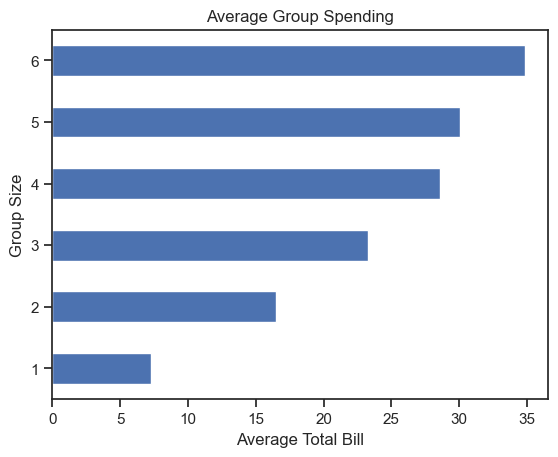

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')
group_spending.plot(kind='barh')

plt.title('Average Group Spending')
plt.ylabel('Group Size')
plt.xlabel('Average Total Bill')

plt.show()

In [33]:
summary = group_spending.reset_index()
summary.columns = ["group_size", "avg_total_bill"]

summary.to_csv("group_spending_summary.csv", index=False)
print("File saved successfully.")


File saved successfully.
